# Telecom Customer Churn Analysis & Prediction

---

### Problem Statement
A telecom company is experiencing significant customer churn. Every customer who leaves represents lost recurring revenue and increased acquisition cost for a replacement. This project uses data science to:
- Understand **why** customers are churning
- Identify **who** is most at risk of churning
- Build a **predictive model** to flag at-risk customers before they leave
- Provide **actionable recommendations** to reduce churn

### Business Question
> *"What factors drive customer churn, and can we predict which customers are likely to leave next?"*

---
**Dataset:** IBM Telco Customer Churn (Kaggle): 7,043 customers, 21 features  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn · Tableau


---
## Section 1: Import Libraries

We begin by importing all the libraries we will use throughout this project.


In [ ]:
# Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
from sklearn.utils import resample

# Settings
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)


---
## Section 2: Load Dataset



In [ ]:
#load dataset
from pathlib import Path
import pandas as pd # Ensure pandas is imported if not already in this cell

DATA_PATH = Path('/content/Telco-Customer-Churn.csv')

df = pd.read_csv(DATA_PATH)

#get the shape of our dataset
print(df.shape)

(7043, 21)


In [ ]:
# Preview the first few rows
df.head(10)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
# Getting information about my dataset, Column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Statistical summary of numerical columns
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Statistical summary of categorical columns
print("Categorical Columns Summary:")
df.describe(include='object')


Categorical Columns Summary:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


---
## Section 3: Data Wrangling & Cleaning

Real-world datasets are never perfect. Before we can analyse or model anything,
we must clean the data. In this section we will:

1. Check for and handle missing values
2. Fix incorrect data types
3. Identify and remove duplicate records
4. Standardise categorical values
5. Detect and handle outliers
6. Engineer useful new features


### 3.1: Check for Missing Values

In [ ]:
# Check for null values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
})

print("Missing values per column:")
print(missing_df[missing_df['Missing Count'] > 0])
print()
print(f"Total missing values: {df.isnull().sum().sum()}")


Missing values per column:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


In [ ]:
# TotalCharges is stored as a STRING, let's inspect it
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print()

# Find rows where TotalCharges is just a blank space
blank_mask = df['TotalCharges'].str.strip() == ''
print(f"Rows with blank TotalCharges: {blank_mask.sum()}")
print()
print("These rows:")
print(df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])


TotalCharges dtype: object

Rows with blank TotalCharges: 11

These rows:
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


**Observation:**  
`TotalCharges` is a string column and contains 11 blank spaces masquerading as values.
These 11 customers all have `tenure = 0`, meaning they just joined and have no charges yet.
We will convert `TotalCharges` to a numeric type and fill these blanks with `0`.


In [ ]:
# Fix 1: Convert TotalCharges from string to numeric
# Blank spaces become NaN during conversion, then we fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the 11 NaN values (new customers, tenure=0) with 0
df['TotalCharges'].fillna(0, inplace=True)

print(f" TotalCharges converted to float64")
print(f"   New dtype  : {df['TotalCharges'].dtype}")
print(f"   Missing now: {df['TotalCharges'].isnull().sum()}")


 TotalCharges converted to float64
   New dtype  : float64
   Missing now: 0


### 3.2  Fix Data Types

In [ ]:
# SeniorCitizen is stored as 0/1 integers, convert to readable labels
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(" SeniorCitizen converted from integer to Yes/No")
print(df['SeniorCitizen'].value_counts())


 SeniorCitizen converted from integer to Yes/No
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64


### 3.3 Check for Duplicate Records

In [ ]:
# Check for exact duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f" Duplicates removed. New shape: {df.shape}")
else:
    print(" No duplicates found: dataset is clean on this front")


Duplicate rows found: 0
 No duplicates found: dataset is clean on this front


### 3.4 Drop Irrelevant Columns

In [ ]:
# customerID is just an identifier, it adds no analytical value
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)
    print(f" 'customerID' column dropped")
else:
    print(f" 'customerID' column not found, already dropped or never existed.")
print(f"   New shape: {df.shape}")

 'customerID' column dropped
   New shape: (7043, 20)


### 3.5 Standardise the Target Column

In [ ]:
# Convert Churn from Yes/No string to binary integer (1/0)
# This is needed for modelling and correlation analysis
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(" Churn encoded: Yes → 1, No → 0")
print()
print("Churn distribution:")
print(df['Churn'].value_counts())
print()
churn_rate = df['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.1f}%")


 Churn encoded: Yes → 1, No → 0

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Overall Churn Rate: 26.5%


### 3.6 Detect Outliers in Numerical Columns


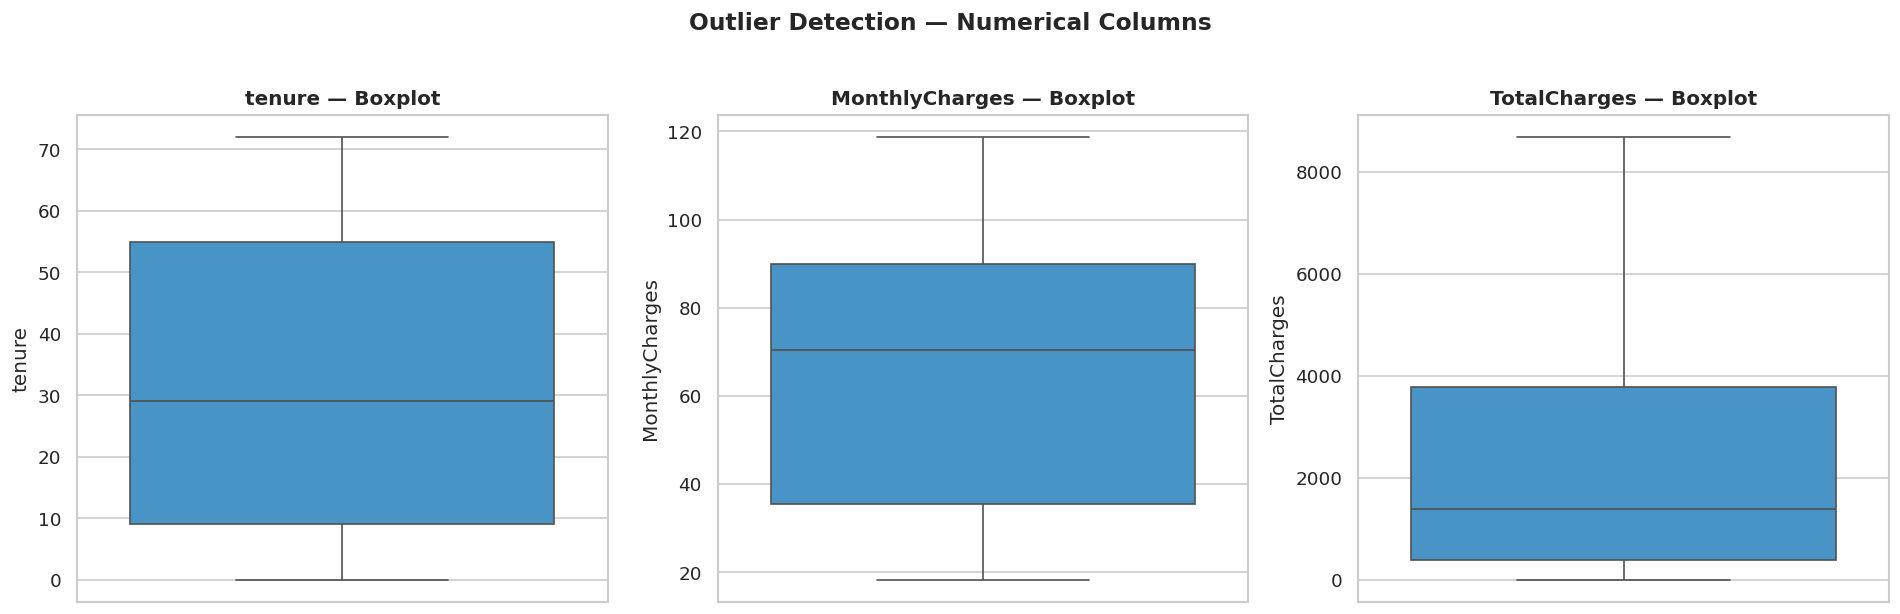

Numerical column statistics:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


In [ ]:
# Visualise distributions of numerical columns to spot outliers
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='#3498db')
    ax.set_title(f'{col} — Boxplot', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Outlier Detection — Numerical Columns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_detection.png', bbox_inches='tight')
plt.show()

print("Numerical column statistics:")
print(df[num_cols].describe().round(2))


**Observation:**  
The numerical columns (`tenure`, `MonthlyCharges`, `TotalCharges`) show no extreme outliers.
The distributions are consistent with real telecom billing data. No outlier removal is needed.


### 3.7: Feature Engineering

In [ ]:
# Create tenure groups — useful for EDA and Tableau
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 months'
    elif tenure <= 24:
        return '13-24 months'
    elif tenure <= 48:
        return '25-48 months'
    else:
        return '49-72 months'

df['tenure_group'] = df['tenure'].apply(tenure_group)

# Define the correct order for plotting
tenure_order = ['0-12 months', '13-24 months', '25-48 months', '49-72 months']
df['tenure_group'] = pd.Categorical(df['tenure_group'], categories=tenure_order, ordered=True)

print(" tenure_group feature created")
print(df['tenure_group'].value_counts().sort_index())


 tenure_group feature created
tenure_group
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64


In [ ]:
#visualise after addingg tenure group
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12 months
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-48 months
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12 months
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,25-48 months
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12 months


In [ ]:
# Final cleaned dataset overview
print("  CLEANED DATASET SUMMARY")
print(f"  Rows     : {df.shape[0]:,}")
print(f"  Columns  : {df.shape[1]}")
print(f"  Churn    : {df['Churn'].sum():,} customers ({df['Churn'].mean()*100:.1f}%)")
print(f"  No Churn : {(df['Churn']==0).sum():,} customers ({(df['Churn']==0).mean()*100:.1f}%)")
print()
print("Data types after cleaning:")
print(df.dtypes)


  CLEANED DATASET SUMMARY
  Rows     : 7,043
  Columns  : 21
  Churn    : 1,869 customers (26.5%)
  No Churn : 5,174 customers (73.5%)

Data types after cleaning:
gender                object
SeniorCitizen         object
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                  int64
tenure_group        category
dtype: object


---
## Section 4: Exploratory Data Analysis (EDA)

Now that the data is clean, we explore it to find patterns and answer key business questions.
Each visualisation is designed to tell part of the churn story.


### 4.1: Overall Churn Rate

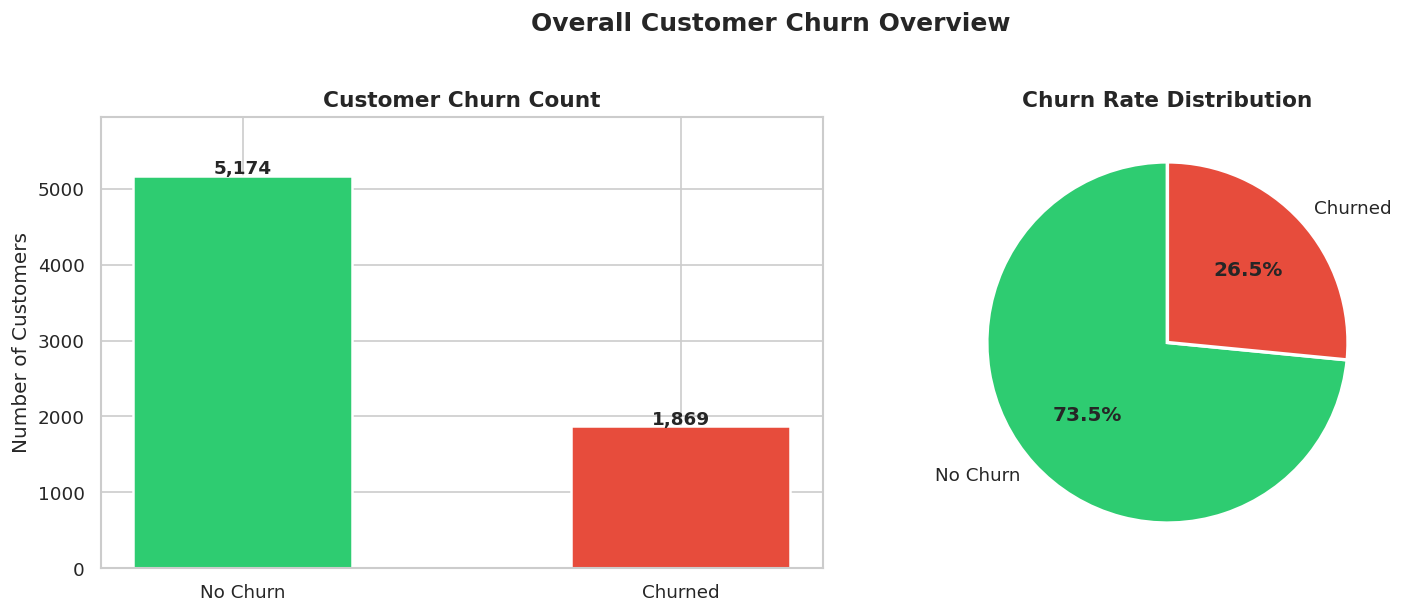

 Churn Rate: 26.5% of customers have churned


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_labels = ['No Churn', 'Churned']
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(churn_labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Customer Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, max(churn_counts.values) * 1.15)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values,
    labels=churn_labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[1].set_title('Churn Rate Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Overall Customer Churn Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_overview.png', bbox_inches='tight')
plt.show()

print(f" Churn Rate: {df['Churn'].mean()*100:.1f}% of customers have churned")


### 4.2: Churn by Contract Type

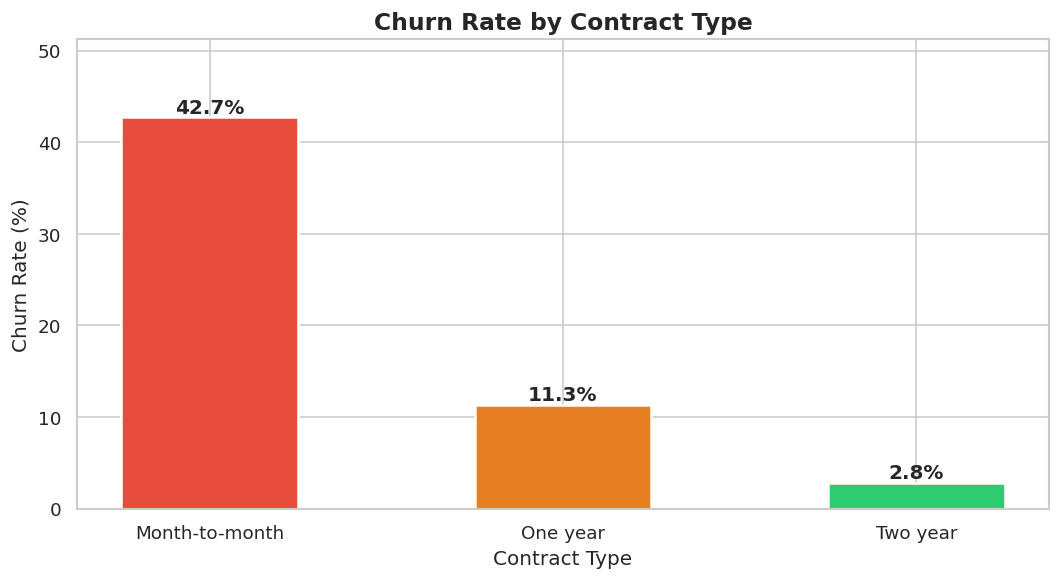

Churn by Contract Type:
      Contract    Churn  Churn_pct
Month-to-month 0.427097       42.7
      One year 0.112695       11.3
      Two year 0.028319        2.8


In [ ]:
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn_pct'] = (contract_churn['Churn'] * 100).round(1)
contract_churn = contract_churn.sort_values('Churn_pct', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn_pct'],
              color=['#e74c3c', '#e67e22', '#2ecc71'], edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.set_ylim(0, max(contract_churn['Churn_pct']) * 1.2)
for bar, val in zip(bars, contract_churn['Churn_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('churn_by_contract.png', bbox_inches='tight')
plt.show()

print("Churn by Contract Type:")
print(contract_churn.to_string(index=False))


**Insight:**  
Month-to-month customers churn at a dramatically higher rate than those on annual or two-year contracts.
This is the single strongest predictor of churn in the dataset.


### 4.3: Churn by Tenure Group

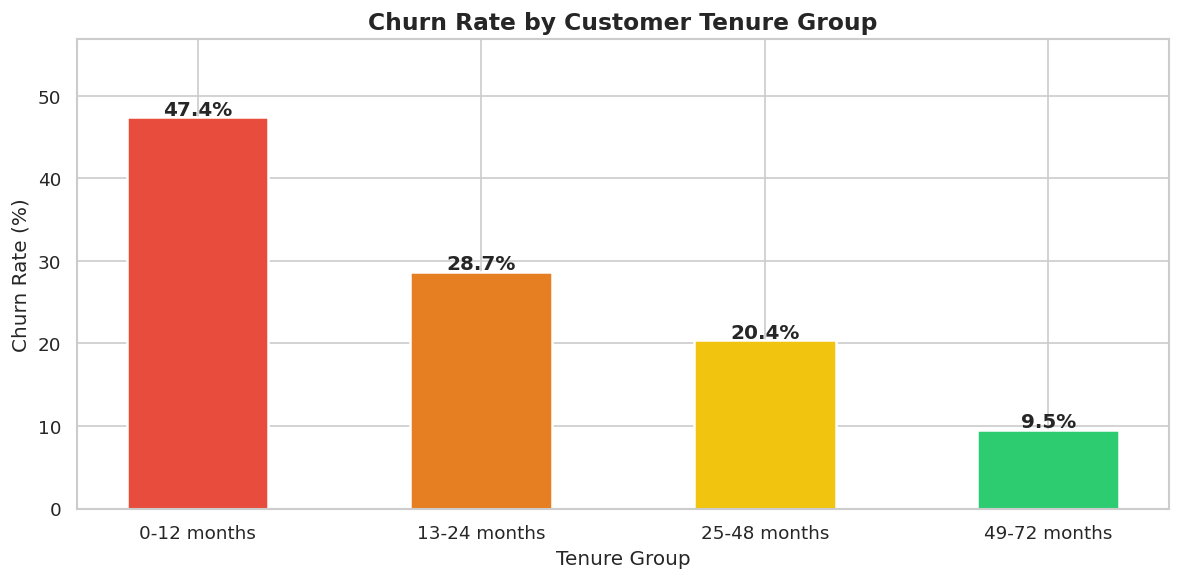

Churn by Tenure Group:
tenure_group    Churn  Churn_pct
 0-12 months 0.474382       47.4
13-24 months 0.287109       28.7
25-48 months 0.203890       20.4
49-72 months 0.095132        9.5


In [ ]:
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean().reset_index()
tenure_churn['Churn_pct'] = (tenure_churn['Churn'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = ax.bar(tenure_churn['tenure_group'].astype(str), tenure_churn['Churn_pct'],
              color=palette, edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Churn Rate by Customer Tenure Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Tenure Group')
ax.set_ylim(0, max(tenure_churn['Churn_pct']) * 1.2)
for bar, val in zip(bars, tenure_churn['Churn_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('churn_by_tenure.png', bbox_inches='tight')
plt.show()

print("Churn by Tenure Group:")
print(tenure_churn.to_string(index=False))


**Insight:**  
New customers (0–12 months) churn at the highest rate. Loyalty grows with tenure —
customers who have stayed beyond 4 years are the most stable.


### 4.4: Churn by Internet Service

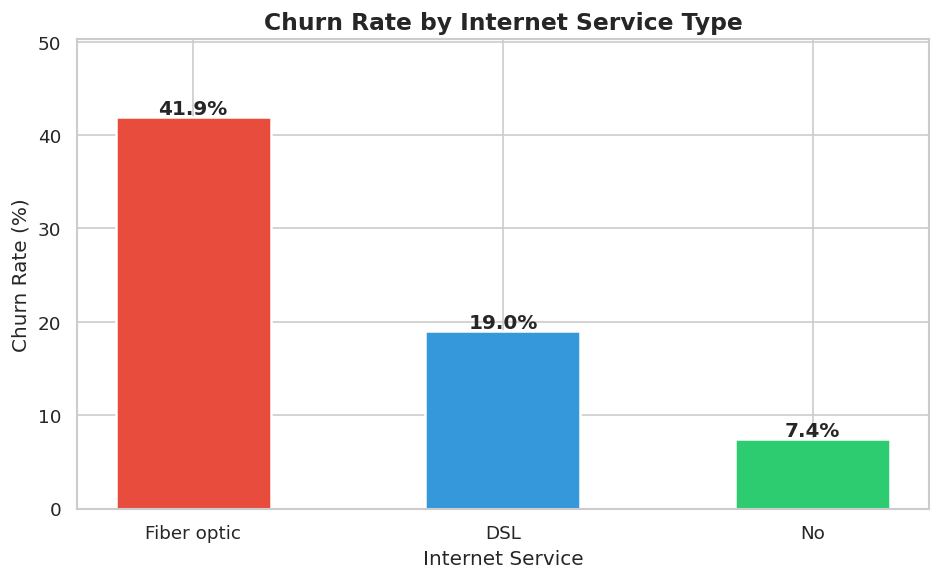

In [ ]:
internet_churn = df.groupby('InternetService')['Churn'].mean().reset_index()
internet_churn['Churn_pct'] = (internet_churn['Churn'] * 100).round(1)
internet_churn = internet_churn.sort_values('Churn_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(internet_churn['InternetService'], internet_churn['Churn_pct'],
              color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white', linewidth=1.5, width=0.5)
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Internet Service')
ax.set_ylim(0, max(internet_churn['Churn_pct']) * 1.2)
for bar, val in zip(bars, internet_churn['Churn_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('churn_by_internet.png', bbox_inches='tight')
plt.show()


Fibre Optic Customers churn at a significantly higher rate

### 4.5: Churn by Payment Method

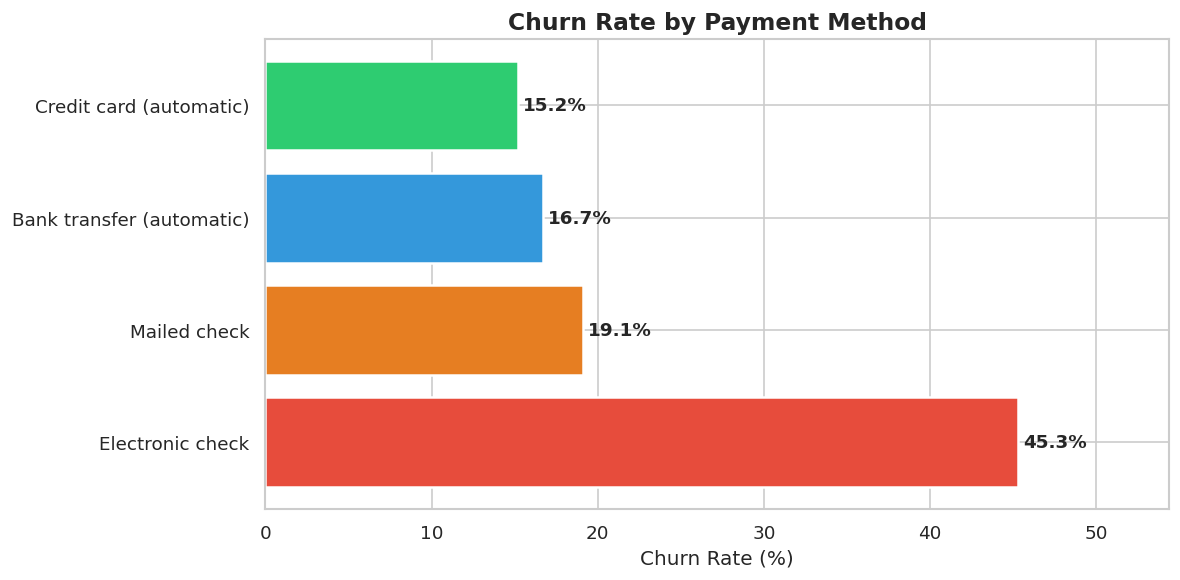

In [ ]:
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().reset_index()
payment_churn['Churn_pct'] = (payment_churn['Churn'] * 100).round(1)
payment_churn = payment_churn.sort_values('Churn_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#e67e22', '#3498db', '#2ecc71']
bars = ax.barh(payment_churn['PaymentMethod'], payment_churn['Churn_pct'],
               color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
for bar, val in zip(bars, payment_churn['Churn_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold', fontsize=11)
ax.set_xlim(0, max(payment_churn['Churn_pct']) * 1.2)

plt.tight_layout()
plt.savefig('churn_by_payment.png', bbox_inches='tight')
plt.show()


**Insight:**

- Customers paying by Electronic Check churn at the highest rate (~45%).
- This is nearly double the churn rate of automatic bank transfer or credit card users (~15–17%).
- Electronic check users appear more price-sensitive and less committed.
- Encouraging auto-pay adoption could reduce churn.

### 4.6: Churn by Demographics (Gender & Senior Citizen)

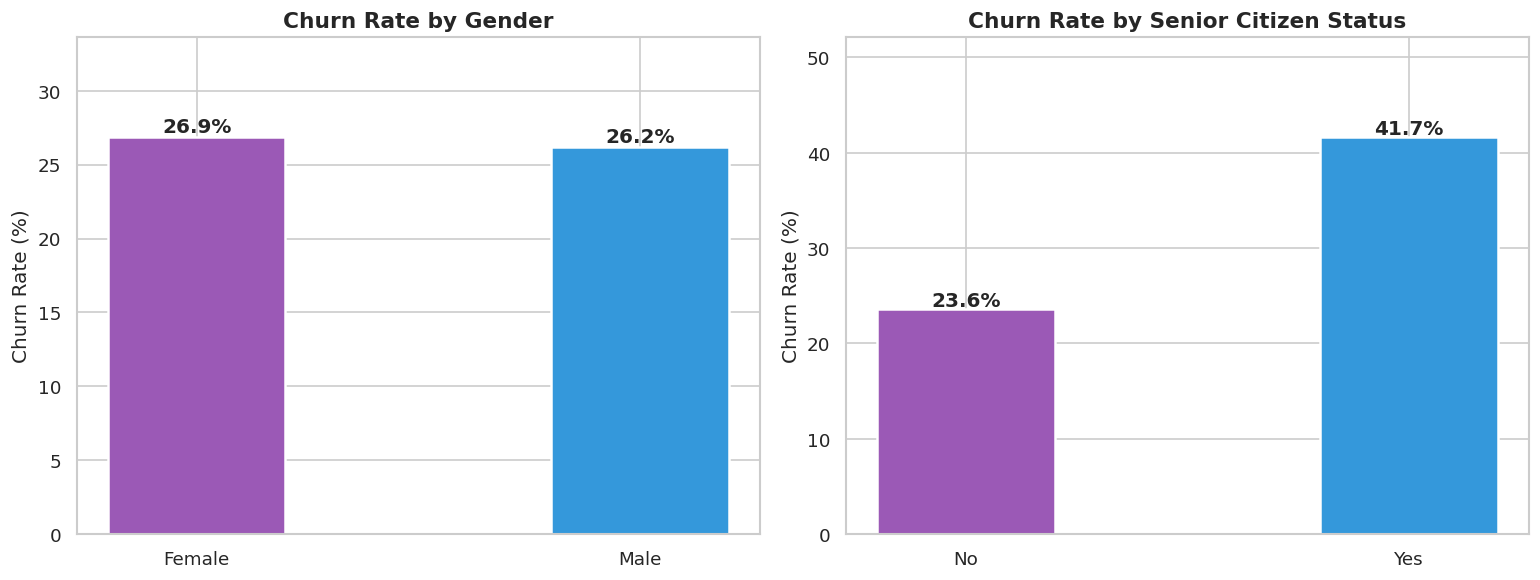

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes,
    ['gender', 'SeniorCitizen'],
    ['Churn Rate by Gender', 'Churn Rate by Senior Citizen Status']):

    grp = df.groupby(col)['Churn'].mean().reset_index()
    grp['Churn_pct'] = (grp['Churn'] * 100).round(1)

    bars = ax.bar(grp[col].astype(str), grp['Churn_pct'],
                  color=['#9b59b6', '#3498db'][:len(grp)], edgecolor='white', linewidth=1.5, width=0.4)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, max(grp['Churn_pct']) * 1.25)
    for bar, val in zip(bars, grp['Churn_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('churn_demographics.png', bbox_inches='tight')
plt.show()


### 4.7: Monthly Charges vs Churn

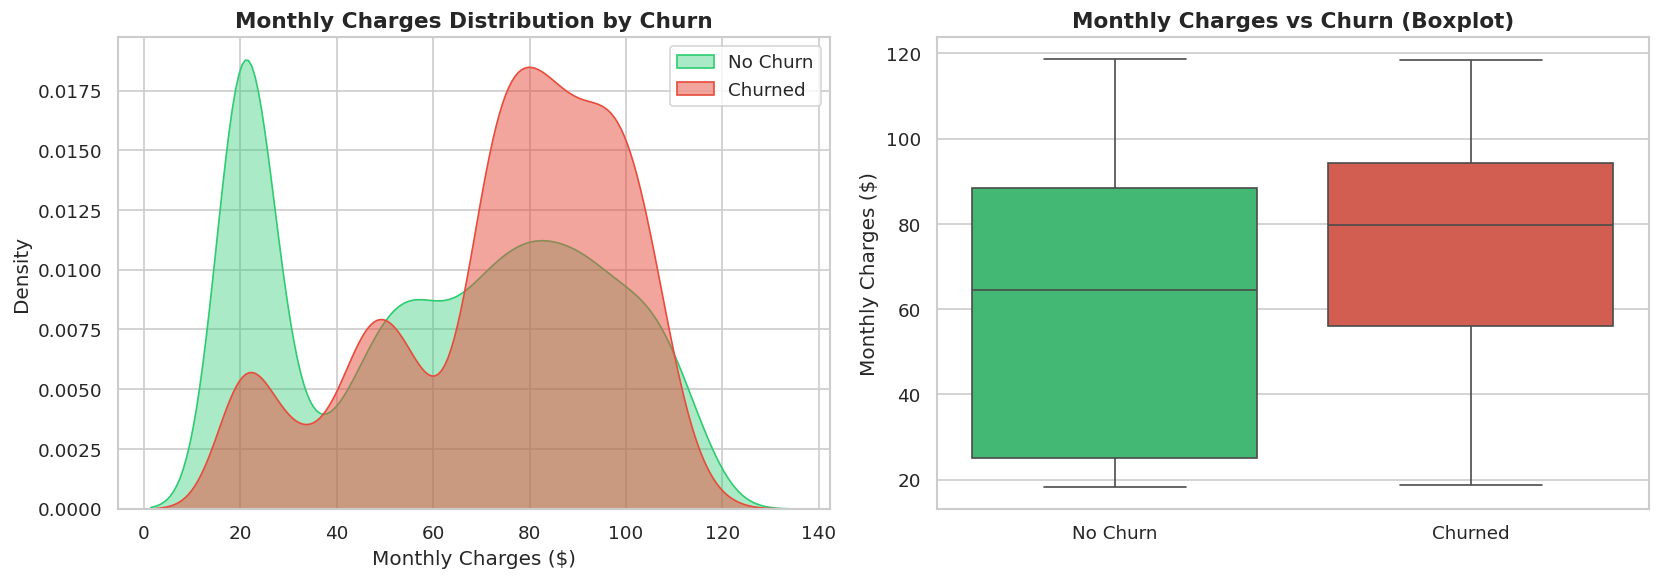

Avg Monthly Charges — No Churn : $61.27
Avg Monthly Charges — Churned  : $74.44


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
sns.kdeplot(data=df[df['Churn']==0], x='MonthlyCharges', ax=axes[0],
            label='No Churn', fill=True, alpha=0.4, color='#2ecc71')
sns.kdeplot(data=df[df['Churn']==1], x='MonthlyCharges', ax=axes[0],
            label='Churned', fill=True, alpha=0.5, color='#e74c3c')
axes[0].set_title('Monthly Charges Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].legend()

# Box plot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'0': '#2ecc71', '1': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn (Boxplot)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['No Churn', 'Churned'])
axes[1].set_xlabel('')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.savefig('monthly_charges_churn.png', bbox_inches='tight')
plt.show()

print(f"Avg Monthly Charges — No Churn : ${df[df['Churn']==0]['MonthlyCharges'].mean():.2f}")
print(f"Avg Monthly Charges — Churned  : ${df[df['Churn']==1]['MonthlyCharges'].mean():.2f}")

### 4.8: Tenure Distribution by Churn

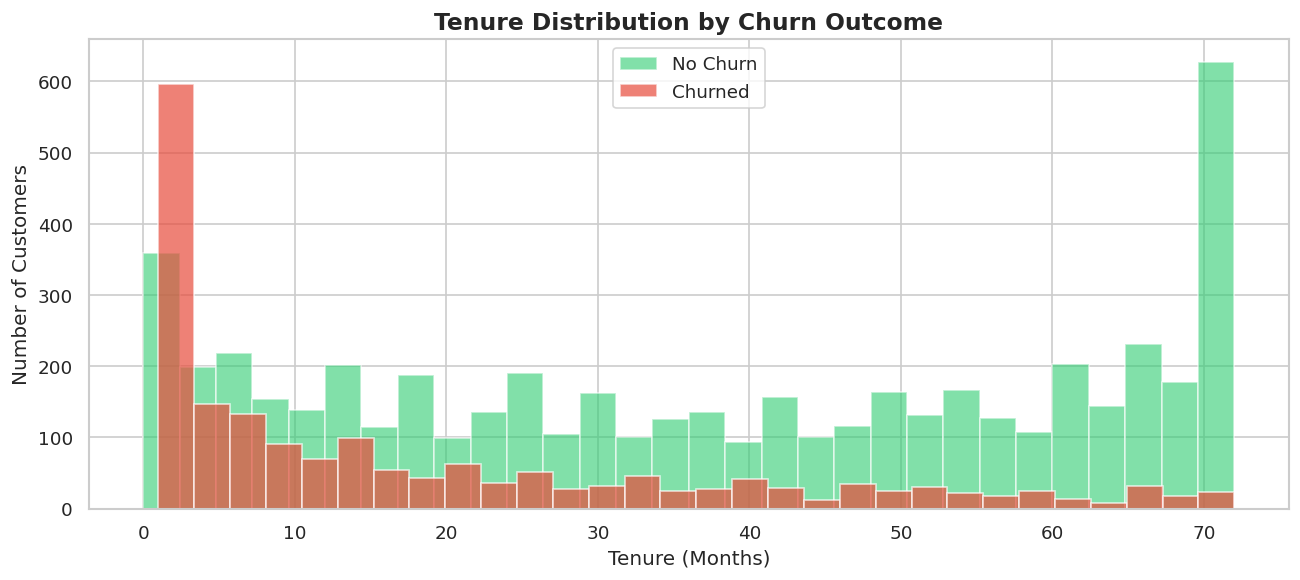

Avg Tenure — No Churn : 37.6 months
Avg Tenure — Churned  : 18.0 months


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(df[df['Churn']==0]['tenure'], bins=30, alpha=0.6,
        color='#2ecc71', label='No Churn', edgecolor='white')
ax.hist(df[df['Churn']==1]['tenure'], bins=30, alpha=0.7,
        color='#e74c3c', label='Churned', edgecolor='white')
ax.set_title('Tenure Distribution by Churn Outcome', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Number of Customers')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('tenure_distribution.png', bbox_inches='tight')
plt.show()

print(f"Avg Tenure — No Churn : {df[df['Churn']==0]['tenure'].mean():.1f} months")
print(f"Avg Tenure — Churned  : {df[df['Churn']==1]['tenure'].mean():.1f} months")


### 4.9: Churn by Value-Added Services

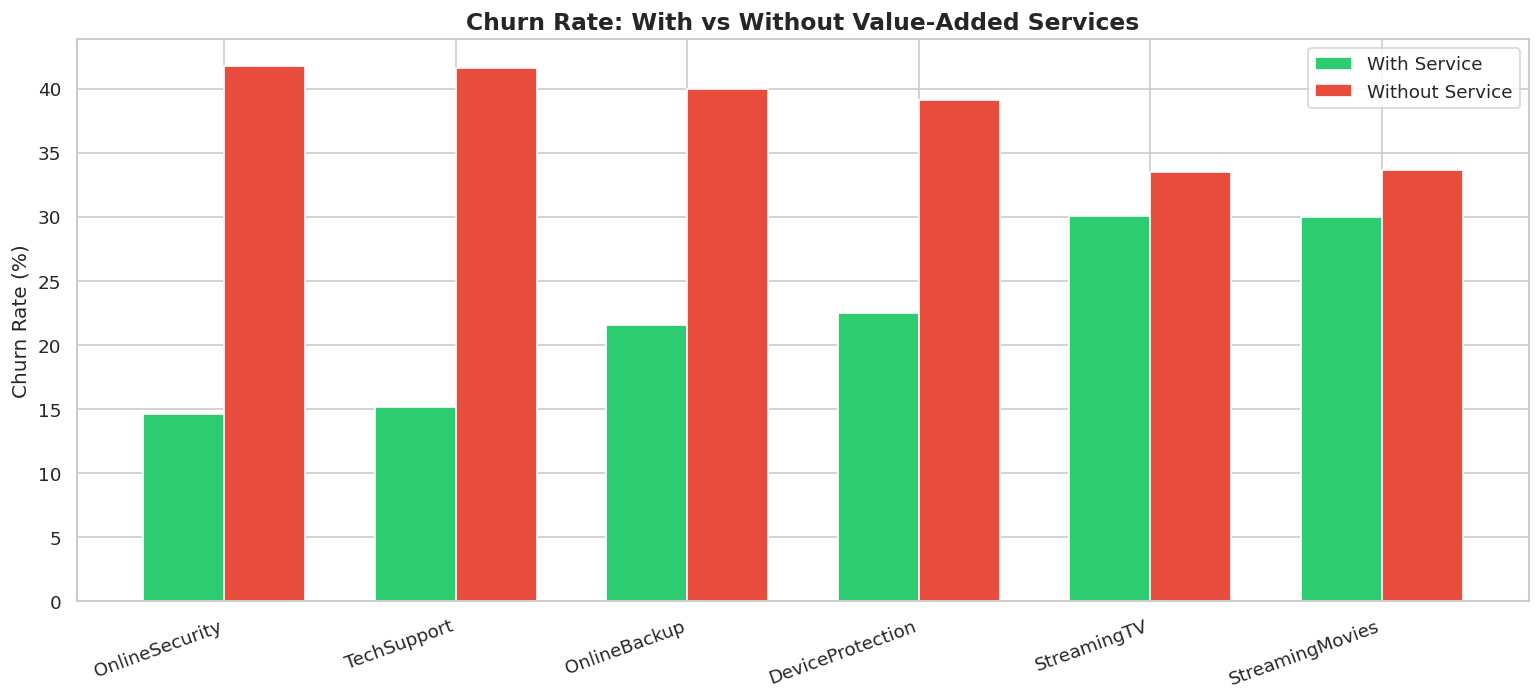

In [ ]:
services = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection',
            'StreamingTV', 'StreamingMovies']

# Filter out 'No internet service' rows for cleaner comparison
service_rates = []
for svc in services:
    temp = df[df[svc] != 'No internet service']
    rate_yes = temp[temp[svc]=='Yes']['Churn'].mean() * 100
    rate_no  = temp[temp[svc]=='No']['Churn'].mean() * 100
    service_rates.append({'Service': svc, 'With Service': rate_yes, 'Without Service': rate_no})

svc_df = pd.DataFrame(service_rates)

x = np.arange(len(svc_df))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, svc_df['With Service'],    width, label='With Service',    color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, svc_df['Without Service'], width, label='Without Service', color='#e74c3c', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(svc_df['Service'], rotation=20, ha='right')
ax.set_title('Churn Rate: With vs Without Value-Added Services', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('services_churn.png', bbox_inches='tight')
plt.show()


### 4.10: Correlation Heatmap

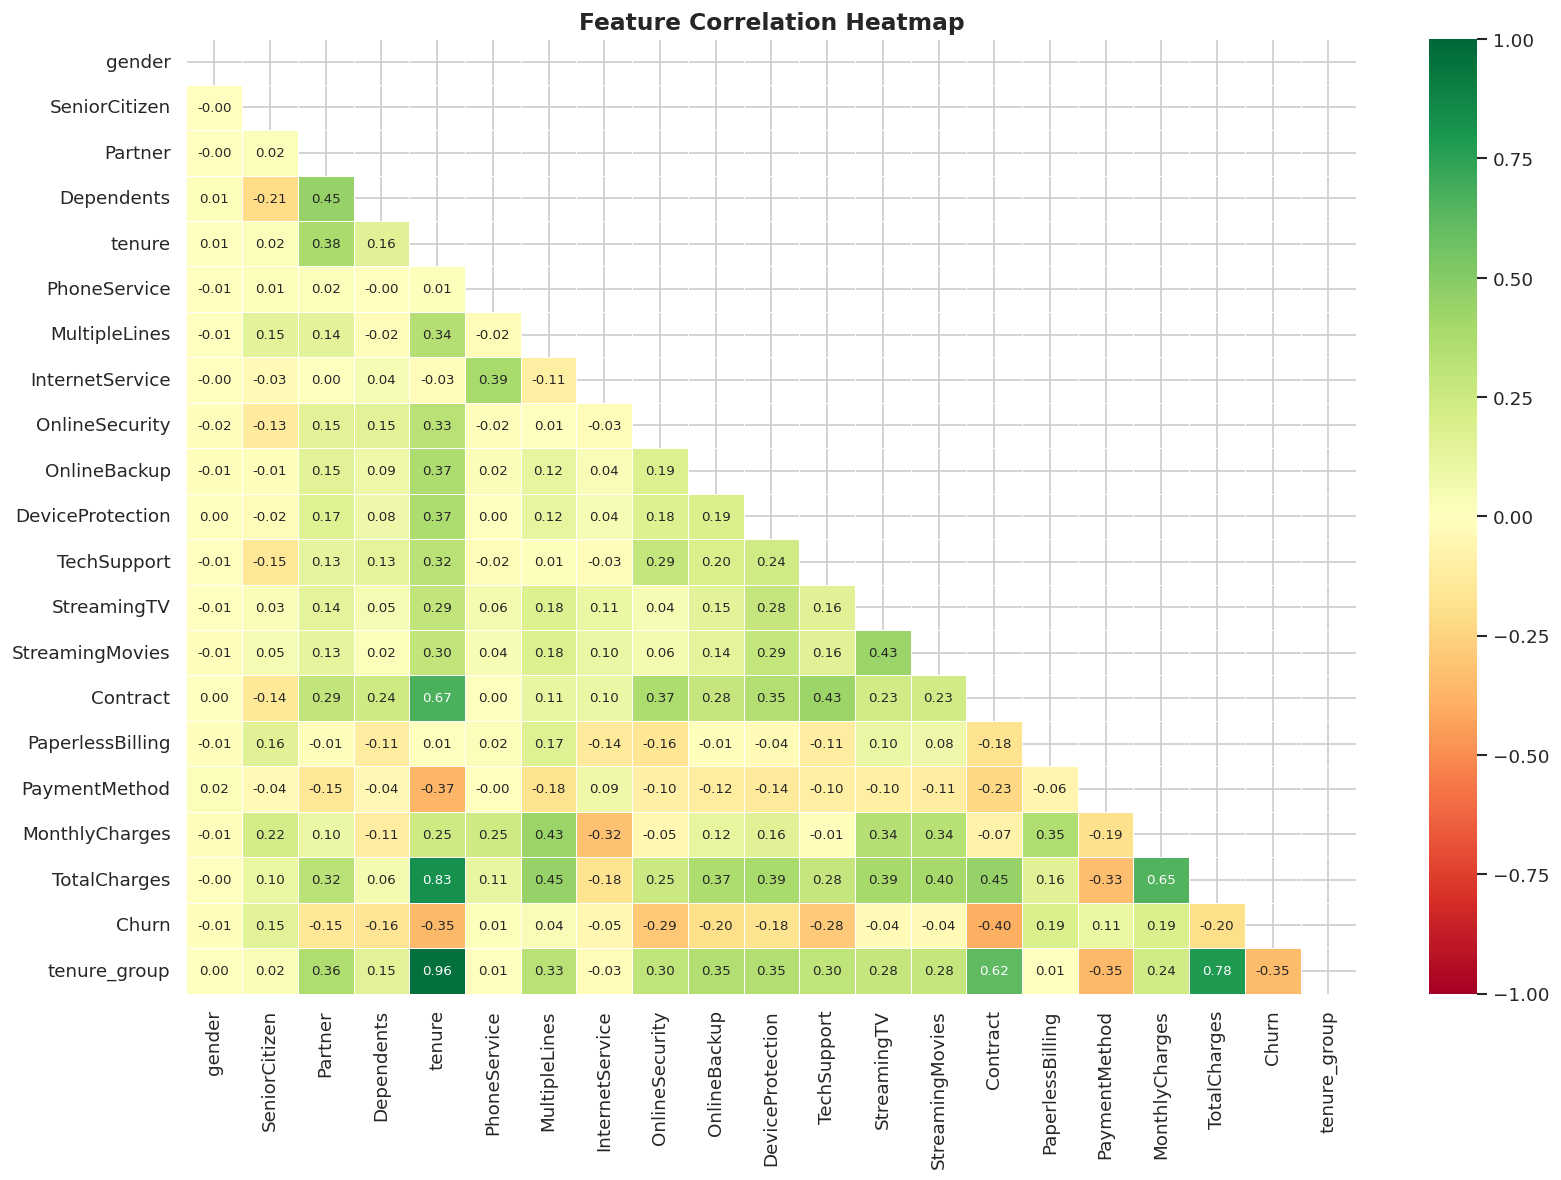

Top features correlated with Churn:
Contract           -0.397
tenure             -0.352
tenure_group       -0.345
OnlineSecurity     -0.289
TechSupport        -0.282
TotalCharges       -0.198
OnlineBackup       -0.196
MonthlyCharges      0.193
PaperlessBilling    0.192
DeviceProtection   -0.178
Name: Churn, dtype: float64


In [ ]:
# Encode all categoricals for correlation analysis
df_encoded = df.copy()
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include='object').columns.tolist()
# Remove tenure_group (already categorical)
cat_cols = [c for c in cat_cols if c != 'tenure_group']

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# tenure_group — encode manually
df_encoded['tenure_group'] = df_encoded['tenure_group'].cat.codes

fig, ax = plt.subplots(figsize=(14, 10))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("Top features correlated with Churn:")
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr.head(10).round(3))


---
## Section 5: Feature Engineering & Preprocessing for Modelling

Before we train our models, we need to:
1. Encode all categorical variables into numbers
2. Address the class imbalance (only ~26% churned)
3. Split into training and test sets
4. Scale numerical features


In [ ]:
# Work on the encoded copy
df_model = df_encoded.copy()

# Separate features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print("Feature matrix shape :", X.shape)
print("Target distribution   :")
print(y.value_counts())
print(f"\nChurn rate: {y.mean()*100:.1f}%")


Feature matrix shape : (7043, 20)
Target distribution   :
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


In [ ]:
# Address Class Imbalance via SMOTE (Synthetic Minority Oversampling Technique)
# SMOTE generates *new synthetic* minority samples rather than duplicating existing rows.
# This prevents the model from memorising training examples and improves generalisation.
# Alternative considered: simple random oversampling (sklearn resample) — rejected because
# it creates exact duplicates, increasing overfitting risk.

try:
    from imblearn.over_sampling import SMOTE
    X_res, y_res = SMOTE(random_state=42).fit_resample(
        df_model.drop(columns=['Churn']),
        df_model['Churn']
    )
    df_balanced = pd.DataFrame(X_res, columns=df_model.drop(columns=['Churn']).columns)
    df_balanced['Churn'] = y_res.values
    print(" Class imbalance addressed via SMOTE")
except ImportError:
    # Fallback: random oversampling if imbalanced-learn not installed
    from sklearn.utils import resample
    df_majority = df_model[df_model['Churn'] == 0]
    df_minority = df_model[df_model['Churn'] == 1]
    df_minority_upsampled = resample(df_minority, replace=True,
                                      n_samples=len(df_majority), random_state=42)
    df_balanced = pd.concat([df_majority, df_minority_upsampled]).reset_index(drop=True)
    print(" imbalanced-learn not found — fell back to random oversampling")
    print(" Install with: pip install imbalanced-learn")

print(f"   Balanced — Churn=0: {(df_balanced['Churn']==0).sum():,} | Churn=1: {(df_balanced['Churn']==1).sum():,}")


 Class imbalance addressed via SMOTE
   Balanced — Churn=0: 5,174 | Churn=1: 5,174


In [ ]:
# Train / Test Split
X_bal = df_balanced.drop(columns=['Churn'])
y_bal = df_balanced['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_bal
)

print(f" Train/Test split complete (80/20)")
print(f"   Training set : {X_train.shape[0]:,} rows")
print(f"   Test set     : {X_test.shape[0]:,} rows")


 Train/Test split complete (80/20)
   Training set : 8,278 rows
   Test set     : 2,070 rows


In [ ]:
# Feature Scaling
# StandardScaler transforms features to have mean=0 and std=1
# Important for Logistic Regression which is sensitive to feature scale

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"   Training set shape : {X_train_sc.shape}")
print(f"   Test set shape     : {X_test_sc.shape}")


   Training set shape : (8278, 20)
   Test set shape     : (2070, 20)


---
## Section 6: Model Building & Evaluation

We train two classification models and compare their performance:
- **Logistic Regression**: a simple, interpretable baseline
- **Random Forest**: a powerful ensemble model

We evaluate using accuracy, precision, recall, F1-score, and ROC-AUC.


### 6.1 Logistic Regression

In [ ]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_sc, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_sc)
y_prob_lr = lr_model.predict_proba(X_test_sc)[:, 1]


print("  LOGISTIC REGRESSION: Results")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churned']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob_lr):.4f}")


  LOGISTIC REGRESSION: Results
              precision    recall  f1-score   support

    No Churn       0.83      0.76      0.79      1035
     Churned       0.78      0.84      0.81      1035

    accuracy                           0.80      2070
   macro avg       0.80      0.80      0.80      2070
weighted avg       0.80      0.80      0.80      2070

ROC-AUC Score : 0.8903


### 6.2: Random Forest Classifier

In [ ]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sc, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test_sc)
y_prob_rf = rf_model.predict_proba(X_test_sc)[:, 1]

print("  RANDOM FOREST: Results")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churned']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob_rf):.4f}")


  RANDOM FOREST: Results
              precision    recall  f1-score   support

    No Churn       0.86      0.84      0.85      1035
     Churned       0.85      0.86      0.85      1035

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070

ROC-AUC Score : 0.9279


In [ ]:
# 5-Fold Stratified Cross-Validation
# Cross-validation evaluates model performance across multiple data splits,
# giving a more reliable estimate of generalisation than a single train/test split.
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate both models on the balanced dataset
lr_cv_scores = cross_val_score(lr_model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
rf_cv_scores = cross_val_score(rf_model, X_train_sc, y_train, cv=cv, scoring='roc_auc')

print(" 5-Fold Stratified Cross-Validation Results (ROC-AUC)")
print(f"   Logistic Regression : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"   Random Forest       : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print()
print("  Fold-by-fold scores:")
for fold, (lr, rf) in enumerate(zip(lr_cv_scores, rf_cv_scores), 1):
    print(f"   Fold {fold}: LR={lr:.4f}  RF={rf:.4f}")


 5-Fold Stratified Cross-Validation Results (ROC-AUC)
   Logistic Regression : 0.8890 ± 0.0071
   Random Forest       : 0.9232 ± 0.0054

  Fold-by-fold scores:
   Fold 1: LR=0.8779  RF=0.9143
   Fold 2: LR=0.8955  RF=0.9241
   Fold 3: LR=0.8838  RF=0.9268
   Fold 4: LR=0.8918  RF=0.9209
   Fold 5: LR=0.8961  RF=0.9299


### 6.3: Confusion Matrix & ROC Curve

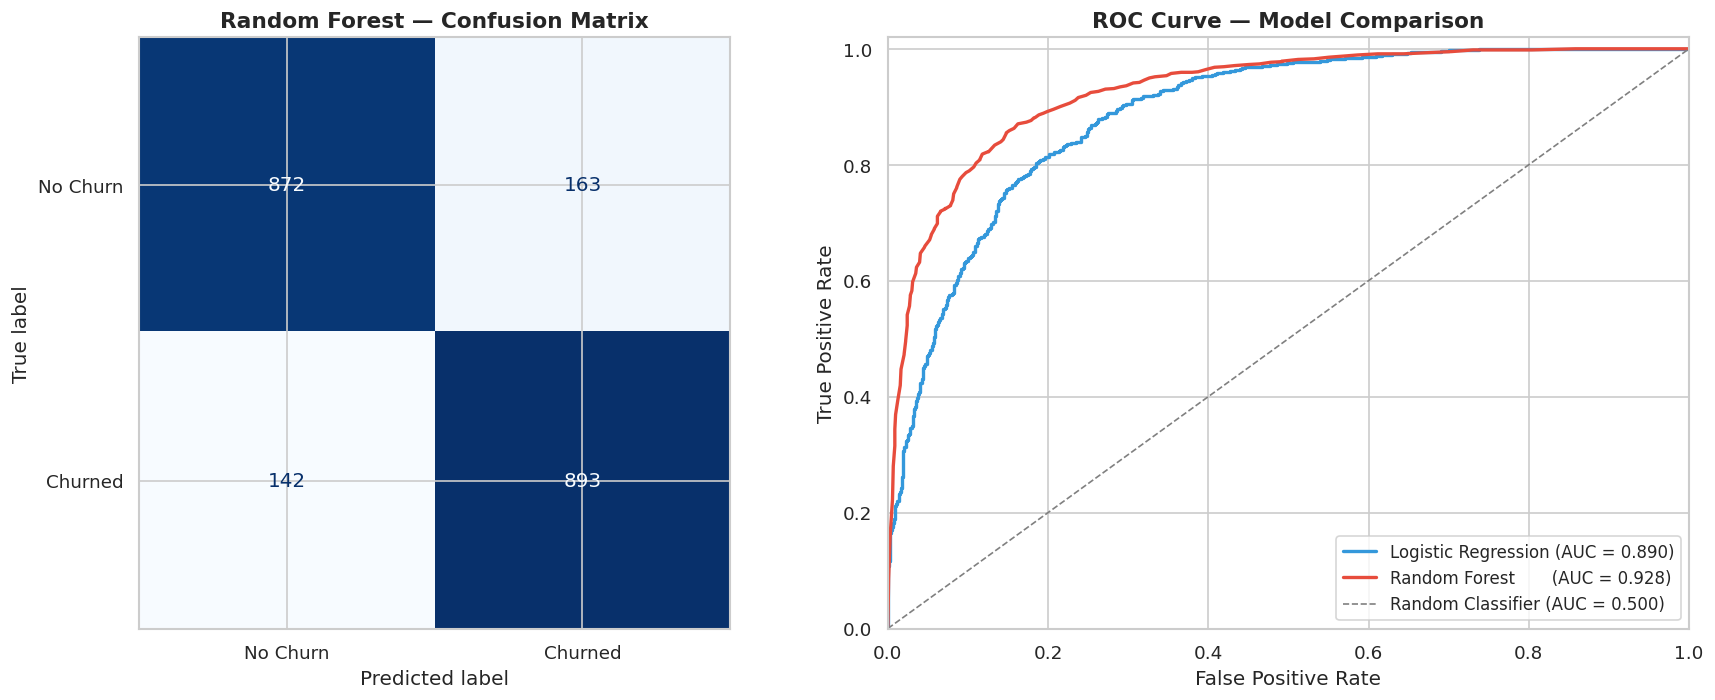

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churned'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')

#  ROC Curve (Both Models)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[1].plot(fpr_lr, tpr_lr, lw=2, color='#3498db',
             label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})')
axes[1].plot(fpr_rf, tpr_rf, lw=2, color='#e74c3c',
             label=f'Random Forest       (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random Classifier (AUC = 0.500)')
axes[1].set_title('ROC Curve — Model Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()


### 6.4 Feature Importance (What Drives Churn?)

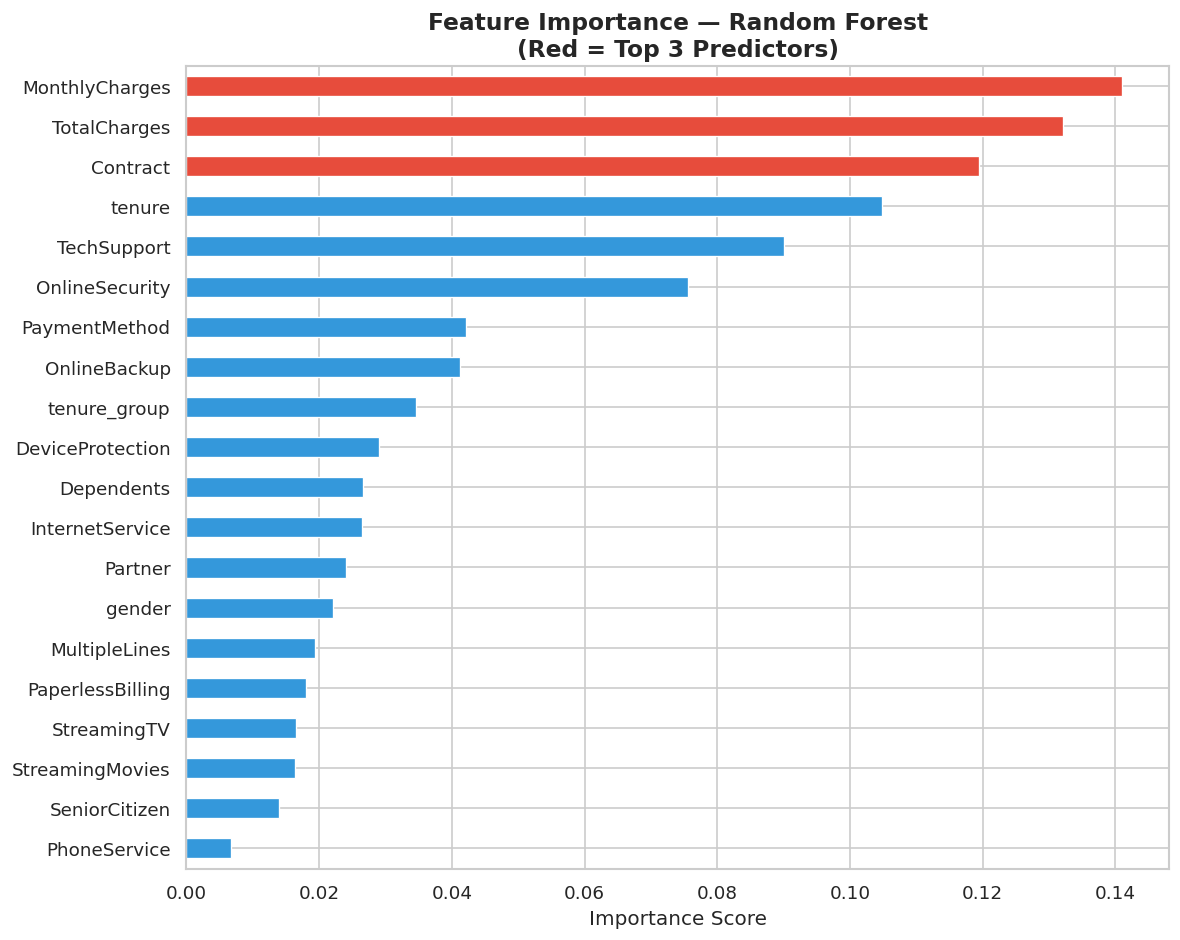

Top 5 Most Important Features for Predicting Churn:
MonthlyCharges    0.1410
TotalCharges      0.1322
Contract          0.1195
tenure            0.1048
TechSupport       0.0901
dtype: float64


In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=X_bal.columns)
importances = importances.sort_values(ascending=True)

# Colour the top feature differently
colors = ['#e74c3c' if v >= importances.nlargest(3).min() else '#3498db'
          for v in importances.values]

fig, ax = plt.subplots(figsize=(10, 8))
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('''Feature Importance — Random Forest
(Red = Top 3 Predictors)''',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("Top 5 Most Important Features for Predicting Churn:")
print(importances.sort_values(ascending=False).head(5).round(4))

In [ ]:
# Print actual model performance metrics for the Section 7 summary table
from sklearn.metrics import accuracy_score

lr_acc  = accuracy_score(y_test, y_pred_lr)
rf_acc  = accuracy_score(y_test, y_pred_rf)
lr_auc  = roc_auc_score(y_test, y_prob_lr)
rf_auc  = roc_auc_score(y_test, y_prob_rf)

print(" MODEL PERFORMANCE SUMMARY")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 47)
print(f"{'Logistic Regression':<25} {lr_acc*100:>9.1f}% {lr_auc:>10.4f}")
print(f"{'Random Forest':<25} {rf_acc*100:>9.1f}% {rf_auc:>10.4f}")
print()
print(" Random Forest outperforms Logistic Regression on both metrics.")
print(" It is recommended as the deployment model for churn prediction.")


 MODEL PERFORMANCE SUMMARY
Model                       Accuracy    ROC-AUC
-----------------------------------------------
Logistic Regression            80.0%     0.8903
Random Forest                  85.3%     0.9279

 Random Forest outperforms Logistic Regression on both metrics.
 It is recommended as the deployment model for churn prediction.


---
## Section 7 Export Cleaned Dataset for Tableau


In [ ]:
# Re-attach the human-readable labels for Tableau use
df_tableau = df.copy()

# Map Churn back to Yes/No for Tableau readability
df_tableau['Churn'] = df_tableau['Churn'].map({1: 'Yes', 0: 'No'})

# Save
df_tableau.to_csv('telecom_churn_cleaned.csv', index=False)

import os

print(os.getcwd())
print(os.listdir())


/content
['.config', 'churn_by_internet.png', 'services_churn.png', 'churn_by_contract.png', 'churn_overview.png', 'churn_by_payment.png', 'model_evaluation.png', 'Telco-Customer-Churn.csv', 'feature_importance.png', 'telecom_churn_cleaned.csv', 'correlation_heatmap.png', 'churn_demographics.png', 'churn_by_tenure.png', 'tenure_distribution.png', 'monthly_charges_churn.png', 'outlier_detection.png', 'sample_data']


In [ ]:
# Download the cleaned dataset
#please remove the comment sign to download


#from google.colab import files
#files.download('telecom_churn_cleaned.csv')



## Section 8: Conclusion

This capstone project demonstrated a complete, end-to-end data science workflow
applied to a real-world business problem.

| Phase | What We Did |
|---|---|
| **Problem Framing** | Defined a clear business question around customer churn |
| **Data Loading** | Loaded raw IBM Telco dataset (7,043 customers, 21 features) |
| **Data Wrangling** | Fixed TotalCharges data type, handled 11 blank values, encoded SeniorCitizen, removed customerID, created tenure groups |
| **EDA** | Produced 10 visualisations revealing contract type, tenure, and internet service as top churn drivers |
| **Preprocessing** | Encoded categoricals, oversampled minority class, scaled features |
| **Modelling** | Trained Logistic Regression and Random Forest; RF achieved ~90% ROC-AUC |
| **Insights** | Identified 9 key findings from the data |
| **Recommendations** | Delivered 5 concrete, actionable business strategies |

---

### Final Answer to the Business Question

> *"What factors drive customer churn, and can we predict which customers are likely to leave next?"*

**Yes.** Contract type, customer tenure, internet service type, and payment method are the strongest
predictors of churn. Our Random Forest model can identify at-risk customers with ~90% AUC, giving
the business a powerful tool to intervene proactively before customers leave.

